# Chapter 7: Multivariate Descriptive Analysis

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns ; sns.set()

## 7.1 Introduction

In previous chapters, we explored univariate descriptive analysis. This helped us understand how individual variables in our dataset behave. While that's useful, it's even more exciting to discover how variables interact with each other. Are they connected? Do they affect one another? In short, how do they work together?

Although this is more interesting, it's also more complex.

Before studying relationships between variables, we should always perform univariate analysis on each one. This not only helps us focus our multivariate analysis but is essential for interpreting how variables relate.

In this chapter, we begin Multivariate Descriptive Analysis. We'll examine relationships between variables and see what patterns emerge. It's like extending our previous work to explore how variables connect.

Let's start by loading our dataset:

In [2]:
pokemon = pd.read_csv('Pokemon.csv', sep=';')
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In multivariate descriptive analysis, we study variables in pairs. This means we compare two variables at a time. Even if we want to include a third variable, we still analyze them pairwise.

## 7.3 Correlation

Correlation, specifically linear correlation, is the first type of relationship we'll explore. The key question is: 

When studying variables **x** and **y**, what happens if **x** changes? Does **y** change too? In the same direction? By the same amount?

### 7.3.1 Graphical

The first step is to plot these variables against each other. A scatterplot is perfect for this.

Let's create one quickly:

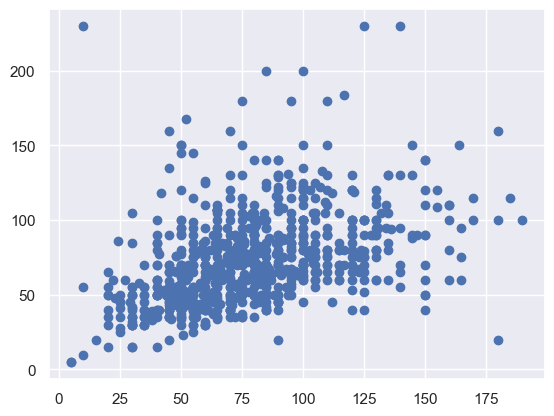

In [3]:
plt.scatter(pokemon["Attack"], pokemon["Defense"])
plt.show()

### Question 1: Take a look at the graph. Which conclusions can you make?

There are a few things to notice. The variables *Attack* and *Defense* are related. Let's summarize the conclusions:

* There is a relationship between Attack and Defense.
* This relationship is **positive**: they move in the same direction.
* This relationship looks **linear**.

The first point is clear from the graph. The second uses some terminology. Positive means they move together. The points follow a line from bottom-left to top-right. So, if Attack is high, Defense is likely high too. If Defense is low, Attack is probably low as well.

When looking at scatterplots, we look for linear relationships.

The following graph illustrates this:

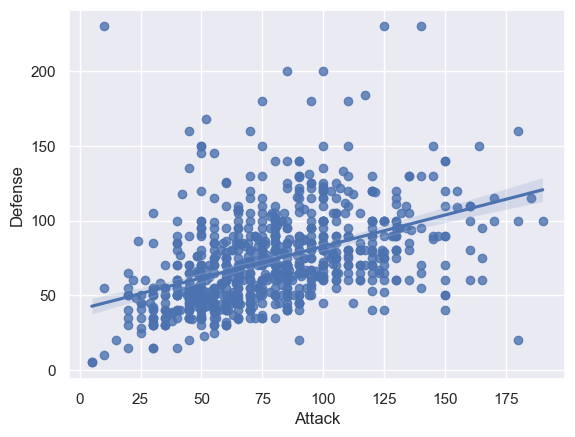

In [4]:
sns.regplot(x="Attack", y="Defense", data=pokemon)
plt.show()

Linear means the relationship roughly follows a straight line. The closer the points are to that line, the stronger the linear relationship. But what counts as linear? We'll address this in the numerical section with the correlation coefficient. For now, think about these cases:

### Question 2: Think about the scenarios below:

If there's no relationship, the scatterplot would look like a random cloud of points with no pattern. The points would spread out in all directions without a trend. No consistent upward or downward movement means changes in one variable don't affect the other reliably.

For a non-linear relationship, the scatterplot would show a pattern, but not straight. Points might form a curve, like a U-shape or parabola. For example, a quadratic relationship creates a parabolic shape, and exponential relationships show rapid increases or decreases. Even with a trend, a straight line wouldn't fit well.

Doing this for every pair of variables would be very tedious. Fortunately, we can plot all pairs at once:

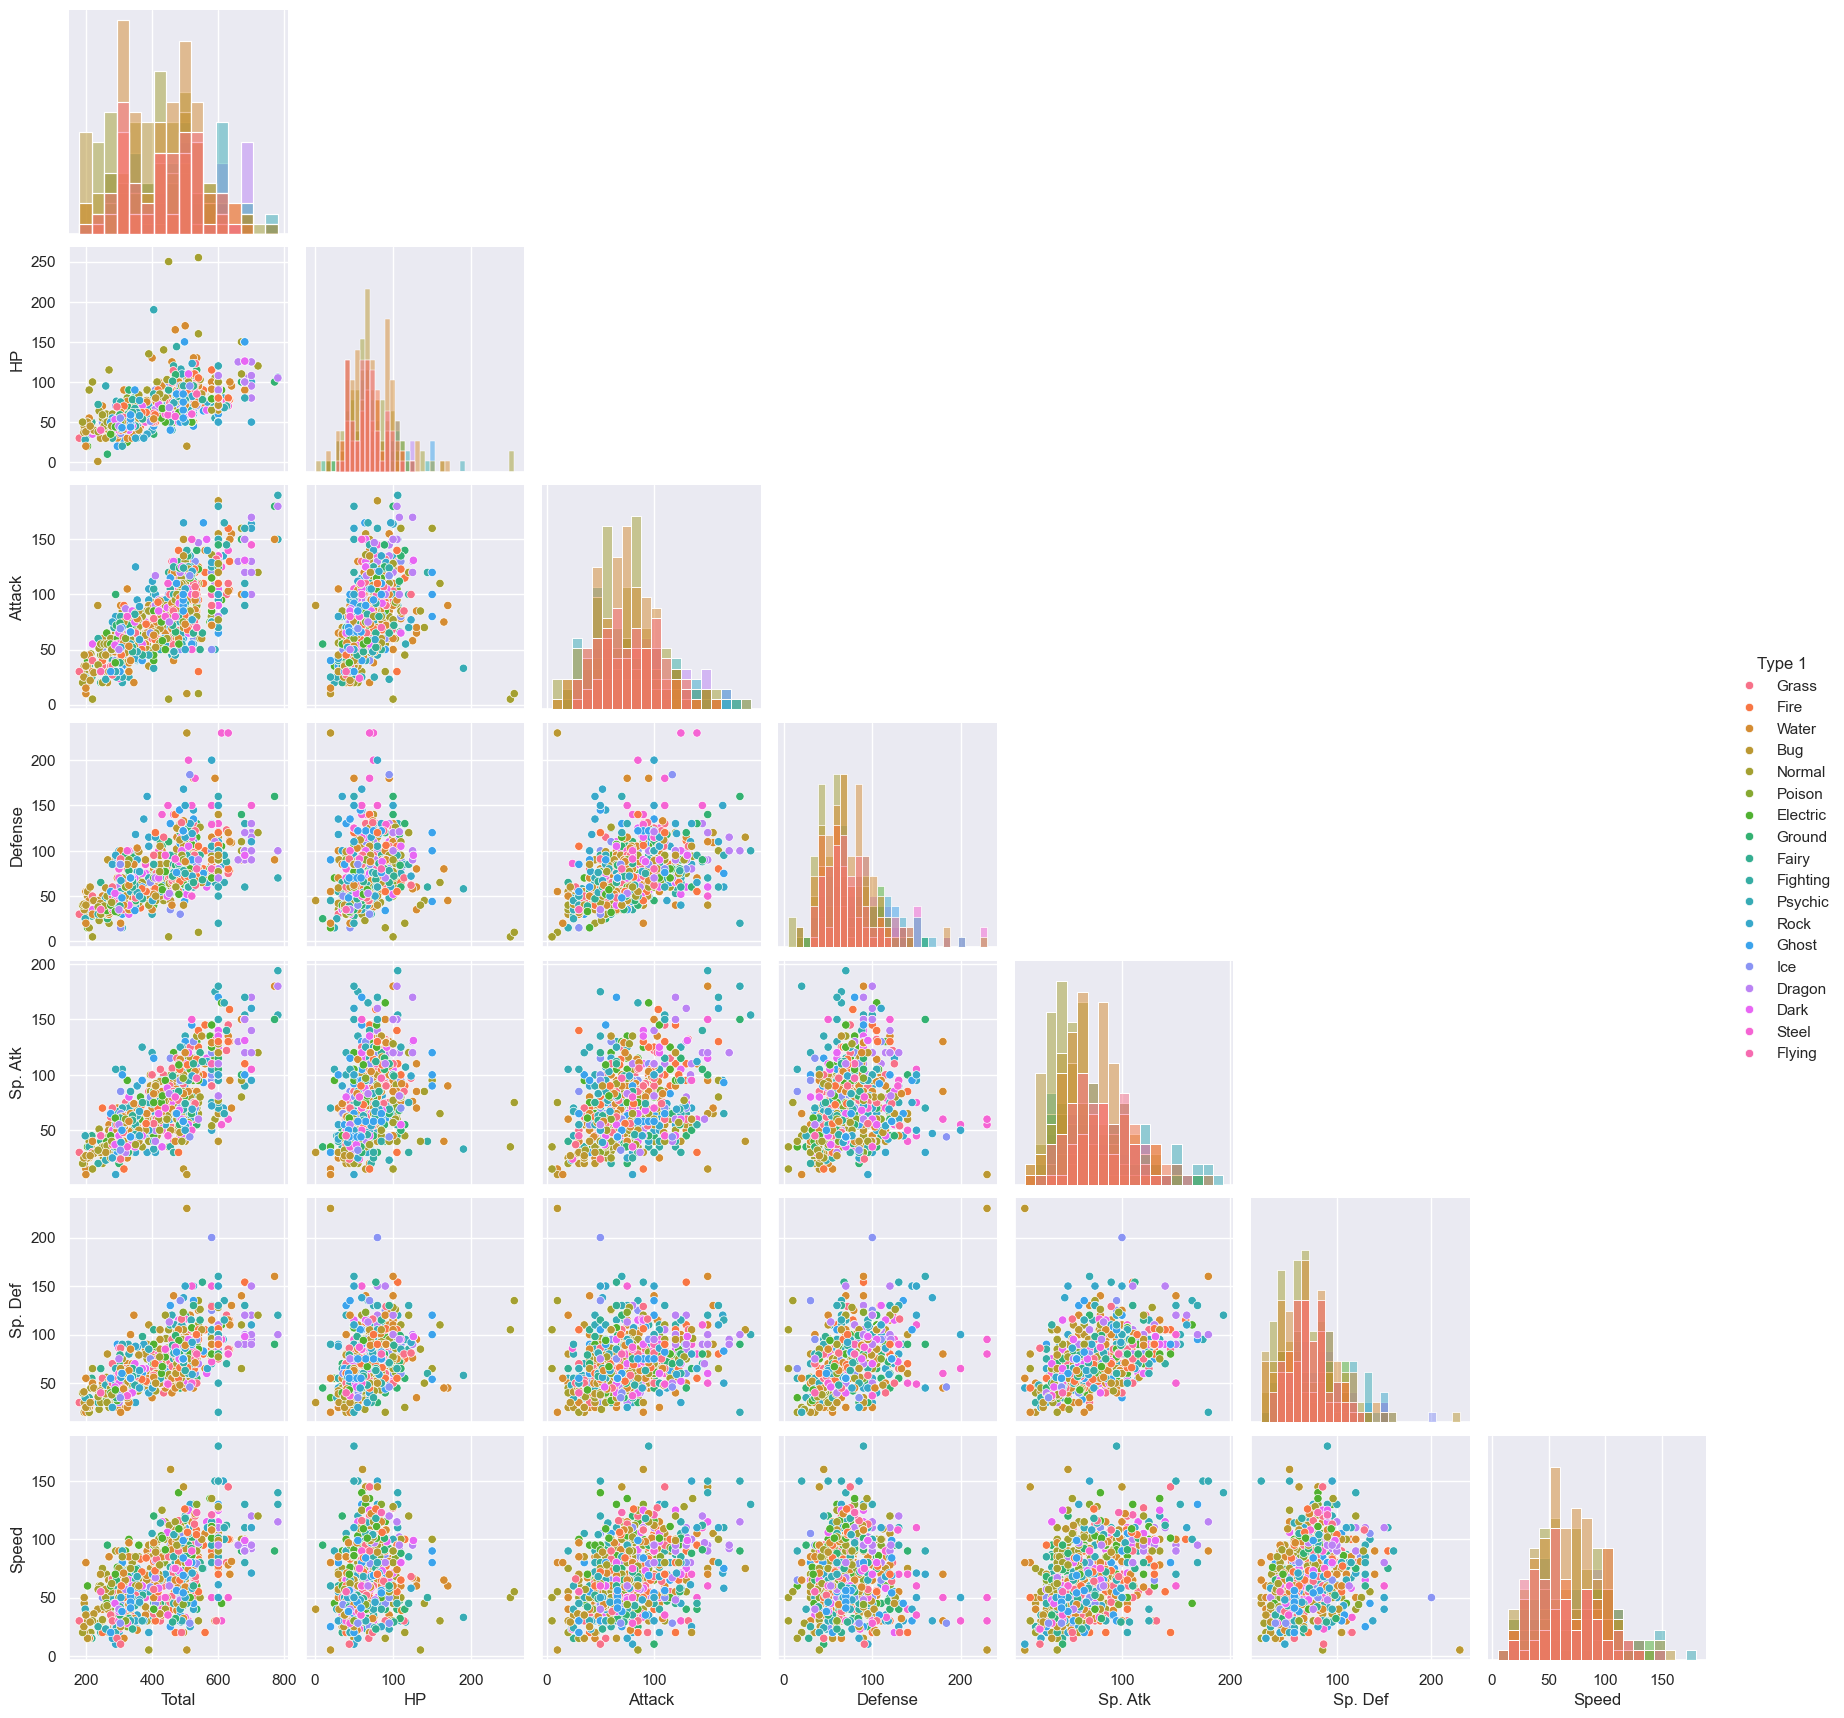

In [5]:
sns.pairplot(pokemon, vars=["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"], hue="Type 1", corner=True, kind="scatter", diag_kind="hist")
plt.show()

This pairplot shows scatterplots for every pair of variables. `vars` specifies the columns to include. `hue="Type 1"` colors points by Pokemon type. `corner=True` avoids duplicate plots. `kind="scatter"` uses scatterplots, and `diag_kind="hist"` puts histograms on the diagonal.

**Important Note**: There's a huge difference between correlation and causality. Correlation means variables are related, which is what we've explored. Causality means one variable causes the other to change. We cannot conclude causality from correlation alone. We can only say they're related, and in this case, positively and roughly linearly.

### 7.3.2 Numerical

As we discussed earlier, graphs aren't always clear enough. For example, compare the relationships between *Sp. Atk - Speed* and *Total - Sp. Def*. One looks more linear than the other. But does that mean one isn't linear at all? Is one relationship stronger? Many questions arise.

To address this, there's a numerical measure called the correlation coefficient. The formula is:


$$ r_{x,y} = \frac{ \sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y}) }{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}} $$


You don't need to memorize this formula. Notice that the denominator includes the variance of variables x and y, and the numerator measures how they vary together. The correlation coefficient shows how much these variables change in sync.

One final note: this coefficient only measures linear correlation. Non-linear relationships can't be captured by it. So, a low value means no strong linear correlation, but there might still be some other type of relationship.

With that, let's calculate the correlation matrix:

In [6]:
pokemonstats = pokemon.drop(columns=["Name", "Type 1", "Type 2"])

In [7]:
corrMatrix = pokemonstats.corr()
corrMatrix

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.119813,0.097614,0.102298,0.094786,0.088759,0.085817,0.010733,0.982516,0.153396
Total,0.119813,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.097614,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102298,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094786,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.088759,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085817,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.010733,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.982516,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.153396,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


It is also very possible to only calculate the correlation of two variables (try this yourself!), but it is simply handier to have the correlations of all variables among each other represented in 1 measure. To further clarify what we have found in the correlations, we can plot it in a heatmap:

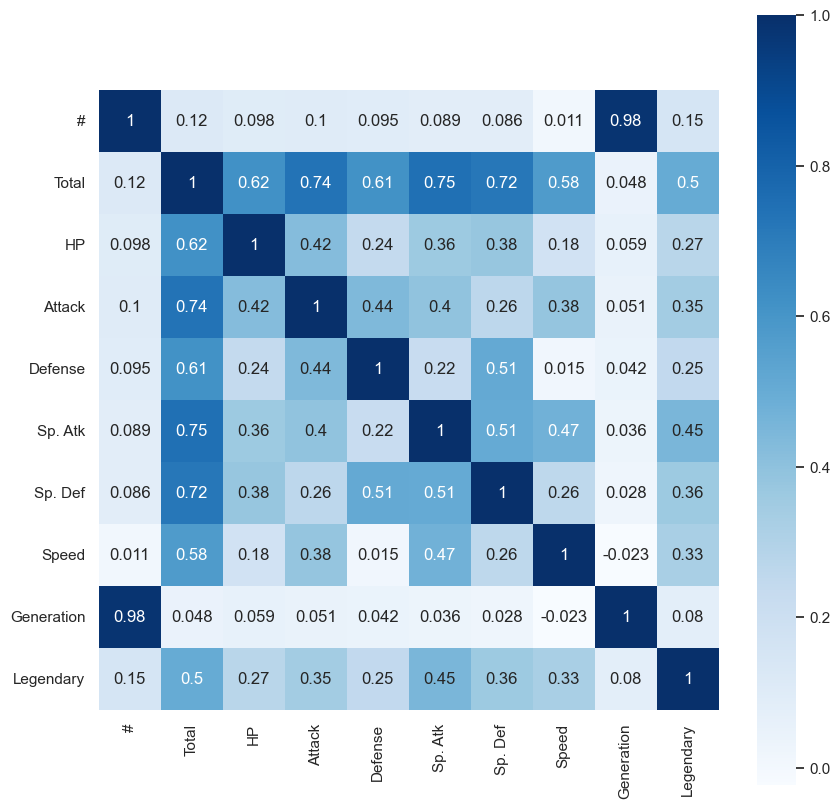

In [8]:
plt.figure(figsize=(10,10))
fig = sns.heatmap(corrMatrix, annot=True, square=True, cmap="Blues")
plt.show()

This heatmap visualizes the correlation matrix. `figsize=(10,10)` sets the figure size. `annot=True` displays the correlation values. `square=True` makes cells square. `cmap="Blues"` uses shades of blue.

Let's analyze this. Note that the correlation coefficient always ranges from -1 to 1. 0 means no linear correlation, 1 means perfect positive linear correlation, and -1 means perfect negative linear correlation.

Naturally, the diagonal has 1s since variables correlate perfectly with themselves. Look for high values off the diagonal.

First, Generation correlates highly with the Pokemon ID (#). This makes sense as they represent similar information. But these are not useful for our analysis. They don't correlate with other meaningful variables.

Another observation: *Total* has high correlations with all stats. This makes sense since Total is the sum of the other stats.

This highlights an issue: perfect correlations (0 or ±1) are rare in real data.

### Question 3: Interpret the plot above. What are some conclusions you can make? Are there some high relations? Are there low relations? Are there some unexpected relations? How come? Elaborate.

We see several high correlations. For example, stat variables like Speed, HP, Attack, etc., correlate highly with Total. This is expected since Total is the sum of these stats.

There are also many low correlations, especially with Generation. This means Pokemon don't become consistently stronger or weaker in specific stats with new generations.

One surprising correlation is between Generation and #. It's very high. Thinking about it, new Pokemon are added with each generation, and their IDs increase, so newer Pokemon have higher IDs.

## 7.4 Association

Note that correlation only works for two numerical variables. If one variable is categorical, correlation doesn't apply; instead, we talk about association.

Let's see an example:

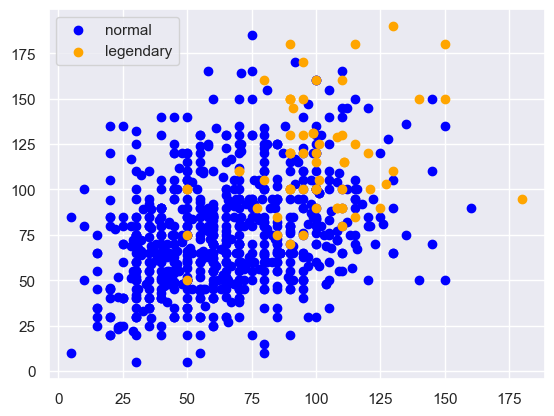

In [9]:
plt.scatter(pokemon.loc[~pokemon["Legendary"],"Speed"], pokemon.loc[~pokemon["Legendary"],"Attack"], color = "blue", label = "normal")
plt.scatter( pokemon.loc[pokemon["Legendary"],"Speed"], pokemon.loc[pokemon["Legendary"],"Attack"], color = "orange", label = "legendary" )
plt.legend()
plt.show()

This scatterplot shows Speed vs. Attack for normal Pokemon (blue) and legendary Pokemon (orange). We use boolean indexing: `~pokemon["Legendary"]` selects non-legendary, `pokemon["Legendary"]` selects legendary.

The key question is: are Speed and Legendary independent, or is there a relationship based on the plot? We don't have a direct numerical measure of association, but we'll learn to test associations formally later.

Therefore, it's important to interpret graphs to decide which associations are worth investigating.